In [359]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import numpy as np


In [360]:
path = "online_gaming_behavior_dataset.csv"
df = pd.read_csv(path)
df['Location'] = df['Location'].replace({'USA': 'America'}) 
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,America,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,America,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,America,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [361]:
#copio dataframe e seleziono le colonne da convertire
df_new = df.copy()
df_drop_playerID = df.drop(columns='PlayerID', inplace=False)
obj_cols = df_new.select_dtypes(include=['object']).columns

df_drop_playerID.head()

,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,29,Female,America,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,22,Female,America,Sports,8.223755,0,Easy,16,142,35,41,High
3,35,Male,America,Action,5.265351,1,Easy,9,85,57,47,Medium
4,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [362]:
df_raw = df_drop_playerID.copy()
# ore settimanali stimate
df_raw['WeeklyTime'] = df_raw['SessionsPerWeek']*df_raw['PlayTimeHours']
#iterazioni di Acquisto
df_raw['MonetizationByGenre'] = df_raw['InGamePurchases']*df_raw['GameGenre']
df_raw["AchievementsUnlockedByLevel"] = df_raw["AchievementsUnlocked"] / (df_raw["PlayerLevel"] + 1)
df_raw["PlayerGnre"] = df_raw["PlayerLevel"] * df_raw["GameGenre"]
df_raw['PurchasesPerHour'] = df_raw['InGamePurchases'] / (df_raw['PlayTimeHours']+1)
df_raw['SessionsPerDay'] = df_raw['SessionsPerWeek'] / 7
df_raw['WeeklyInGamePurchases'] = df_raw['InGamePurchases'] / (df_raw['WeeklyTime']+1)
df_raw['LogPlayTime'] = np.log1p(df_raw['PlayTimeHours'])
df_raw['GenreLevel'] = df_raw['GameGenre'].astype(str) + '_' + df_raw['PlayerLevel'].astype(str)
df_raw['SessionsPerAge'] = df_raw['SessionsPerWeek'] / df_raw['Age']
df_raw['EngagementIntensity'] = df_raw['SessionsPerWeek'] * df_raw['AvgSessionDurationMinutes']

df_raw.head()


,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,...,MonetizationByGenre,AchievementsUnlockedByLevel,PlayerGnre,PurchasesPerHour,SessionsPerDay,WeeklyInGamePurchases,LogPlayTime,GenreLevel,SessionsPerAge,EngagementIntensity
0,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,...,,0.312500,StrategyStrategyStrategyStrategyStrategyStrate...,0.000000,0.857143,0.000000,2.849036,Strategy_79,0.139535,648
1,29,Female,America,Strategy,5.525961,0,Medium,5,144,11,...,,0.833333,StrategyStrategyStrategyStrategyStrategyStrate...,0.000000,0.714286,0.000000,1.875788,Strategy_11,0.172414,720
2,22,Female,America,Sports,8.223755,0,Easy,16,142,35,...,,1.138889,SportsSportsSportsSportsSportsSportsSportsSpor...,0.000000,2.285714,0.000000,2.221782,Sports_35,0.727273,2272
3,35,Male,America,Action,5.265351,1,Easy,9,85,57,...,Action,0.810345,ActionActionActionActionActionActionActionActi...,0.159608,1.285714,0.020666,1.835035,Action_57,0.257143,765
4,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,...,,0.385417,ActionActionActionActionActionActionActionActi...,0.000000,0.285714,0.000000,2.805295,Action_95,0.060606,262


In [363]:
df_clean = df_raw.drop(['PlayTimeHours','GenreLevel','PlayerGnre','InGamePurchases','WeeklyTime'],axis=1)

In [364]:
df_raw.drop(['InGamePurchases','WeeklyTime'],axis=1)

,Age,Gender,Location,GameGenre,PlayTimeHours,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,...,MonetizationByGenre,AchievementsUnlockedByLevel,PlayerGnre,PurchasesPerHour,SessionsPerDay,WeeklyInGamePurchases,LogPlayTime,GenreLevel,SessionsPerAge,EngagementIntensity
0,43,Male,Other,Strategy,16.271119,Medium,6,108,79,25,...,,0.312500,StrategyStrategyStrategyStrategyStrategyStrate...,0.000000,0.857143,0.000000,2.849036,Strategy_79,0.139535,648
1,29,Female,America,Strategy,5.525961,Medium,5,144,11,10,...,,0.833333,StrategyStrategyStrategyStrategyStrategyStrate...,0.000000,0.714286,0.000000,1.875788,Strategy_11,0.172414,720
2,22,Female,America,Sports,8.223755,Easy,16,142,35,41,...,,1.138889,SportsSportsSportsSportsSportsSportsSportsSpor...,0.000000,2.285714,0.000000,2.221782,Sports_35,0.727273,2272
3,35,Male,America,Action,5.265351,Easy,9,85,57,47,...,Action,0.810345,ActionActionActionActionActionActionActionActi...,0.159608,1.285714,0.020666,1.835035,Action_57,0.257143,765
4,33,Male,Europe,Action,15.531945,Medium,2,131,95,37,...,,0.385417,ActionActionActionActionActionActionActionActi...,0.000000,0.285714,0.000000,2.805295,Action_95,0.060606,262
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,32,Male,America,Strategy,20.619662,Easy,4,75,85,14,...,,0.162791,StrategyStrategyStrategyStrategyStrategyStrate...,0.000000,0.571429,0.000000,3.073603,Strategy_85,0.125000,300
40030,44,Female,Other,Simulation,13.539280,Hard,19,114,71,27,...,,0.375000,SimulationSimulationSimulationSimulationSimula...,0.000000,2.714286,0.000000,2.676854,Simulation_71,0.431818,2166
40031,15,Female,America,RPG,0.240057,Easy,10,176,29,1,...,RPG,0.033333,RPGRPGRPGRPGRPGRPGRPGRPGRPGRPGRPGRPGRPGRPGRPGR...,0.806415,1.428571,0.294068,0.215157,RPG_29,0.666667,1760
40032,34,Male,America,Sports,14.017818,Medium,3,128,70,10,...,Sports,0.140845,SportsSportsSportsSportsSportsSportsSportsSpor...,0.066588,0.428571,0.023227,2.709237,Sports_70,0.088235,384


In [365]:
df_new = df.copy()
df_drop_playerID = df.drop(columns='PlayerID', inplace=False)
obj_cols = df_new.select_dtypes(include=['object']).columns
 
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
data_to_encode = df_drop_playerID[obj_cols]
encoded_data = encoder.fit_transform(data_to_encode)

encoded_df = pd.DataFrame(
    encoded_data, 
    columns=encoder.get_feature_names_out(obj_cols),
    index=df_drop_playerID.index
)

df_final = pd.concat([df_drop_playerID.drop(columns=obj_cols), encoded_df], axis=1)

df_final.head()

,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,Gender_Female,Gender_Male,Location_America,...,GameGenre_RPG,GameGenre_Simulation,GameGenre_Sports,GameGenre_Strategy,GameDifficulty_Easy,GameDifficulty_Hard,GameDifficulty_Medium,EngagementLevel_High,EngagementLevel_Low,EngagementLevel_Medium
0,43,16.271119,0,6,108,79,25,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,29,5.525961,0,5,144,11,10,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,22,8.223755,0,16,142,35,41,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,35,5.265351,1,9,85,57,47,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,33,15.531945,0,2,131,95,37,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [366]:
df_final['EngagementLevel'] = df_final[['EngagementLevel_High', 'EngagementLevel_Medium', 'EngagementLevel_Low']].idxmax(axis=1)
df_final['EngagementLevel'] = df_final['EngagementLevel'].str.replace('EngagementLevel_', '')
df_final = df_final.drop(columns=['EngagementLevel_High', 'EngagementLevel_Medium', 'EngagementLevel_Low'])

In [367]:
X = df_final.drop(["EngagementLevel"],axis=1)
y = df_final["EngagementLevel"]

In [368]:
X_train, X_test ,y_train , y_test = train_test_split(X,y,test_size=.2 ,stratify=y) 

In [369]:
df_final.isna().sum()

Age                          0
PlayTimeHours                0
InGamePurchases              0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
Gender_Female                0
Gender_Male                  0
Location_America             0
Location_Asia                0
Location_Europe              0
Location_Other               0
GameGenre_Action             0
GameGenre_RPG                0
GameGenre_Simulation         0
GameGenre_Sports             0
GameGenre_Strategy           0
GameDifficulty_Easy          0
GameDifficulty_Hard          0
GameDifficulty_Medium        0
EngagementLevel              0
dtype: int64

In [390]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# model = LogisticRegression( solver='saga' ,class_weight="balanced", max_iter=3000 ,random_state=42)
# model.fit(X_train_scaled,y_train)

log_model = LogisticRegression(
    multi_class='multinomial',   # softmax
    solver='lbfgs',              # ottimizzatore adatto
    max_iter=2000,
    class_weight='balanced',     # utile se le classi non sono bilanciate
    random_state=42,
    C=1
)
log_model.fit(X_train_scaled, y_train)

c:\Users\rigel\OneDrive\Desktop\develhope\Data-PT-9-TeamProject-1-team-2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'multinomial'


# METRICHE

In [391]:
y_pred = log_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.80      0.91      0.85      2067
         Low       0.68      0.81      0.74      2065
      Medium       0.87      0.71      0.78      3875

    accuracy                           0.79      8007
   macro avg       0.78      0.81      0.79      8007
weighted avg       0.80      0.79      0.79      8007



In [394]:
acc_score = accuracy_score(y_test,y_pred)
train_acc = log_model.score(X_train_scaled, y_train)
test_acc = log_model.score(X_test_scaled, y_test)

print(f"Accuracy train: {train_acc:.3f}")
print(f"Accuracy test:  {test_acc:.3f}")
print(f"Accuracy score:  {acc_score:.3f}")



Accuracy train: 0.786
Accuracy test:  0.790
Accuracy score:  0.790


 MODEL BALANCED 0.00


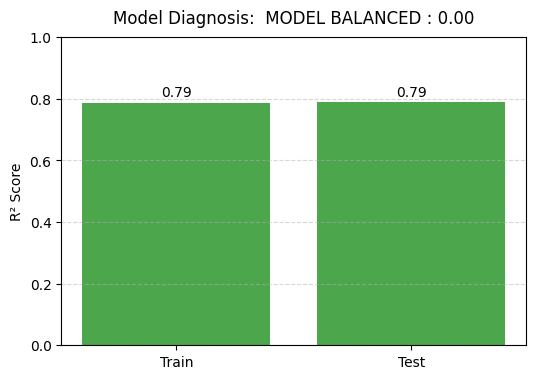

In [397]:
# Calcolo della differenza
spread_score = test_acc - train_acc

# Diagnosi automatica
if spread_score > 0.10:
    status = " OVERFITTING"
    color = "red"
elif spread_score <= -0.05:
    status = " UNDERFITTING"
    color = "blue"
elif train_acc > 0.95 and test_acc > 0.95:
    status = " POSSIBLE DATA LEAKAGE"
    color = "orange"
else:
    status = " MODEL BALANCED"
    color = "green"

print(f"{status} {spread_score:.2f}")



plt.figure(figsize=(6,4))
plt.bar(["Train", "Test"], [train_acc, test_acc], color=[color, color], alpha=0.7)
plt.ylim(0, 1)
plt.ylabel("R² Score")
plt.title(f"Model Diagnosis: {status} : {spread_score:.2f}", fontsize=12, pad=10)
plt.text(0, train_acc + 0.02, f"{train_acc:.2f}", ha='center', color='black', fontsize=10)
plt.text(1, test_acc + 0.02, f"{test_acc:.2f}", ha='center', color='black', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [373]:
new_order = ["High", "Medium", "Low"]
original_labels = log_model.classes_
cm = confusion_matrix(y_test, y_pred, labels=log_model.classes_)
cm_df = pd.DataFrame(cm, index=original_labels, columns=original_labels)
cm_df = cm_df.loc[new_order, new_order]
cm_df

,High,Medium,Low
High,1878,115,74
Medium,408,2767,700
Low,74,313,1678


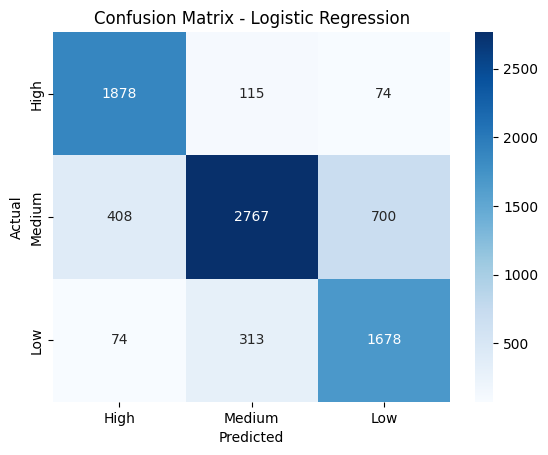

In [374]:
sns.heatmap (cm_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [375]:
print(y_pred[:10])
print(y_test[:10].values)

['High' 'Medium' 'High' 'Medium' 'Low' 'High' 'Medium' 'High' 'Low'
 'Medium']
['High' 'Low' 'Medium' 'Medium' 'Low' 'Low' 'Medium' 'High' 'Low' 'Medium']


In [376]:
y_pred_proba = log_model.predict_proba(X_test_scaled)
print(y_pred_proba[:5])

[[0.70924815 0.00897346 0.28177839]
 [0.02514827 0.44964734 0.52520439]
 [0.50328219 0.05744482 0.43927298]
 [0.4017672  0.14502162 0.45321118]
 [0.00407334 0.70084827 0.29507839]]


In [377]:
y.value_counts(normalize=True)

EngagementLevel
Medium    0.483939
High      0.258181
Low       0.257881
Name: proportion, dtype: float64

In [378]:
print(X_test.columns.tolist() == X.columns.tolist())

True


# GRAFICO DELLE FEATURE PIÙ IMPORTANTI

In [379]:
y_pred = log_model.predict(X_test)
print(pd.Series(y_pred).value_counts(normalize=True))
# ! NEW

High    1.0
Name: proportion, dtype: float64


c:\Users\rigel\OneDrive\Desktop\develhope\Data-PT-9-TeamProject-1-team-2\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


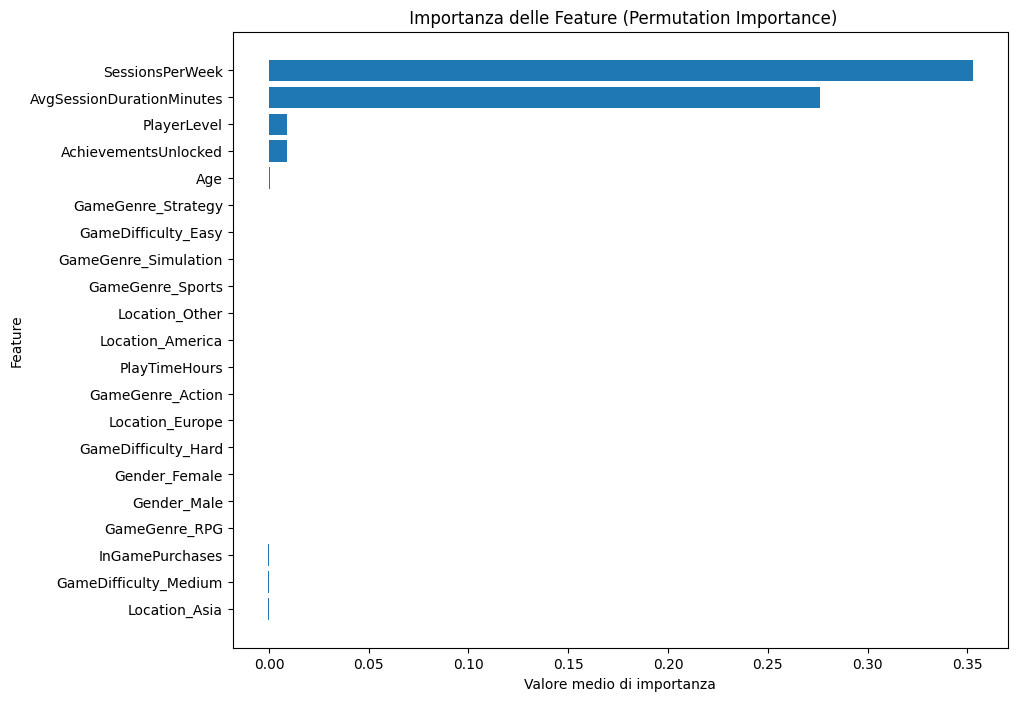

,Feature,Importance
10,Location_Asia,-0.000487
20,GameDifficulty_Medium,-0.000375
2,InGamePurchases,-0.000337
14,GameGenre_RPG,-0.000162
8,Gender_Male,-0.000150
7,Gender_Female,-0.000150
19,GameDifficulty_Hard,-0.000137
11,Location_Europe,-0.000125
13,GameGenre_Action,-0.000112
1,PlayTimeHours,-0.000100


In [380]:
from sklearn.inspection import permutation_importance
X_test_scaled = scaler.transform(X_test)
result = permutation_importance(log_model, X_test_scaled, y_test, n_repeats=10, random_state=42)

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=True)


plt.figure(figsize=(10, 8))
plt.barh(importances['Feature'], importances['Importance'])
plt.title(' Importanza delle Feature (Permutation Importance)')
plt.xlabel('Valore medio di importanza')
plt.ylabel('Feature')
plt.show()

importances.head(23)
# ! NEW

In [381]:
important_features = importances[importances['Importance'] > 0.001]['Feature']
X_reduced = X[important_features]

X_reduced

,AchievementsUnlocked,PlayerLevel,AvgSessionDurationMinutes,SessionsPerWeek
0,25,79,108,6
1,10,11,144,5
2,41,35,142,16
3,47,57,85,9
4,37,95,131,2
...,...,...,...,...
40029,14,85,75,4
40030,27,71,114,19
40031,1,29,176,10
40032,10,70,128,3


In [382]:


def test_player(model, scaler, X_columns, **kwargs):
    """
    Funzione per testare automaticamente un nuovo giocatore.
    
    Parametri:
        model      -> modello addestrato (es. log_model)
        scaler     -> scaler fit sul training set
        X_columns  -> colonne originali del training (X.columns)
        kwargs     -> valori noti del nuovo giocatore (es. Age=25, PlayTimeHours=10, ecc.)
    
    Output:
        - Predizione della classe (High / Medium / Low)
        - Probabilità per ciascuna classe
    """
    
    # Crea un dizionario con tutte le colonne, impostando a 0 quelle mancanti
    nuovo_record = {col: kwargs.get(col, 0) for col in X_columns}
    
    # Trasforma in DataFrame
    df_4_pred = pd.DataFrame([nuovo_record])
    
    # Applica lo stesso scaler
    df_scaled = scaler.transform(df_4_pred)
    
    # Predizione
    pred = model.predict(df_scaled)[0]
    prob = model.predict_proba(df_scaled)[0]
    
    # Output formattato
    result = pd.DataFrame({
        'Classe': model.classes_,
        'Probabilità': np.round(prob, 3)
    })
    
    print("🎯 Predizione finale:", pred)
    print("\n📊 Dettaglio probabilità:\n")
    display(result.sort_values(by='Probabilità', ascending=False))
    
    return pred, result


In [383]:
test_player(
    log_model, 
    scaler, 
    X.columns,
    Age=35,
    PlayTimeHours=62,
    InGamePurchases=2,
    SessionsPerWeek=5,
    AvgSessionDurationMinutes=95,
    PlayerLevel=0.5,
    AchievementsUnlocked=85,
    Gender_Male=1,
    Location_Asia =0,
    Location_Other = 1,
  
)
# FEATURE NON RILEVANTI
# GameGenre_Simulation	
# GameGenre_Strategy	
# Gender_Female	
# Location_America	
# GameDifficulty_Easy	
# GameDifficulty_Hard	
# GameGenre_Sports	
# GameDifficulty_Medium	
# Location_Europe	
# GameGenre_Action	
# GameGenre_RPG	

🎯 Predizione finale: Medium

📊 Dettaglio probabilità:



,Classe,Probabilità
2,Medium,0.544
1,Low,0.408
0,High,0.048


('Medium',
    Classe  Probabilità
 0    High        0.048
 1     Low        0.408
 2  Medium        0.544)